<a href="https://colab.research.google.com/github/avionerman/AML/blob/main/04_interpretability_w_pgd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Interpretability (course-aligned)

Course-aligned υλοποιησεις με βαση το πρόγραμμα διδασκαλιας. Καλυπτονται:

1. **SHAP** — DeepSHAP attributions στα 2-channel spectrograms.
2. **LIME** — image variant με super-pixel segmentation.
3. **Grad-CAM** — saliency-method default (το syllabus δεν ονοματιζει
   συγκεκριμενη μεθοδο, και ο Grad-CAM ειναι το modern standard).
4. **ProtoPNet sketch** — nearest training prototypes ως ο post-hoc
   ισοδυναμος του "inject interpretability" idea.
5. **Permutation Feature Importance** στα 8 RF-DSP features.

**Διαβαζει** απο `artefacts/01_training_{clean|pgd}/`. **Δεν ξανατρεχει εκπαιδευση.**


## 1. Setup

In [3]:
# Auto-detect environment (Colab vs local) and add src/ to sys.path.
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = Path("/content/drive/MyDrive/rf_drone_defense")
else:
    # local: this notebook lives in <root>/notebooks/, src/ is one level up
    PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(PROJECT))
print("Project root:", PROJECT)
print("Python:", sys.version.split()[0])

import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/rf_drone_defense
Python: 3.12.13
torch 2.10.0+cu128 | CUDA available: True
GPU: NVIDIA L4


In [4]:
from src.config import CFG, CLASS_NAMES, FRIENDLY_IDX, N_CLASSES
from src import data as data_mod
from src import model as model_mod
from src import interpret as interp_mod
from src import causal as causal_mod  # only for the RF feature names

import numpy as np
import torch
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


### 1.1 Επιλογη variant του εκπαιδευμενου μοντελου

Το notebook 01 παραγει **δυο εκδοχες** μοντελου (αν εχετε τρεξει και τα δυο passes):

- `artefacts/01_training_clean/`  → clean baseline (PGD off)
- `artefacts/01_training_pgd/`    → PGD-hardened

Διαλεξτε ποια θελετε να αναλυσετε αλλαζοντας **μια γραμμη** στο cell παρακατω.


In [5]:
# === Επιλογη μοντελου προς αναλυση ===
# False -> διαβαζει απο artefacts/01_training_clean/
# True  -> διαβαζει απο artefacts/01_training_pgd/
CFG.use_adversarial_training = True

print(f"Reading artefacts from: {CFG.artefacts('01_training')}")
assert CFG.artefacts('01_training').exists(), (
    f"Folder missing: {CFG.artefacts('01_training')}. "
    "Have you run 01_training.ipynb for this variant yet?"
)


Reading artefacts from: /content/drive/MyDrive/rf_drone_defense/artefacts/01_training_pgd


## 2. Φορτωση μοντελου + sample batch

In [6]:
art01 = CFG.artefacts("01_training")
splits_file = np.load(art01 / "splits.npz")
train_idx, val_idx, test_idx = splits_file["train"], splits_file["val"], splits_file["test"]

pack = data_mod.load_arrays(CFG.dataset_path, with_iq=False)
x_spec, y, snr = pack["x_spec"], pack["y"], pack["snr"]

_, _, test_loader = data_mod.make_loaders(
    (train_idx, val_idx, test_idx), x_spec, y, snr, cfg=CFG, augment_train=False,
)

model = model_mod.build_model(N_CLASSES).to(DEVICE)
state = torch.load(art01 / "checkpoints" / "best.pt", map_location=DEVICE, weights_only=True)
model.load_state_dict(state); model.eval()

# Grab one batch of clean test samples.
xb, yb, sb = next(iter(test_loader))
xb_dev = xb.to(DEVICE)
yb_t = torch.as_tensor(yb, device=DEVICE)
print("batch:", xb.shape, "labels:", yb.tolist()[:6])


batch: torch.Size([128, 2, 128, 128]) labels: [0, 0, 0, 0, 0, 0]


## 3. SHAP (DeepSHAP)

In [7]:
import torch.nn as nn
from torchvision.models.resnet import BasicBlock

# Disable inplace ReLU
for m in model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False

# Monkey-patch BasicBlock.forward to use non-inplace add
def _safe_forward(self, x):
    identity = x
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    if self.downsample is not None:
        identity = self.downsample(x)
    out = out + identity   # was: out += identity
    out = self.relu(out)
    return out

BasicBlock.forward = _safe_forward
print("model is now SHAP-safe (inplace ReLU + residual add neutralised)")


model is now SHAP-safe (inplace ReLU + residual add neutralised)


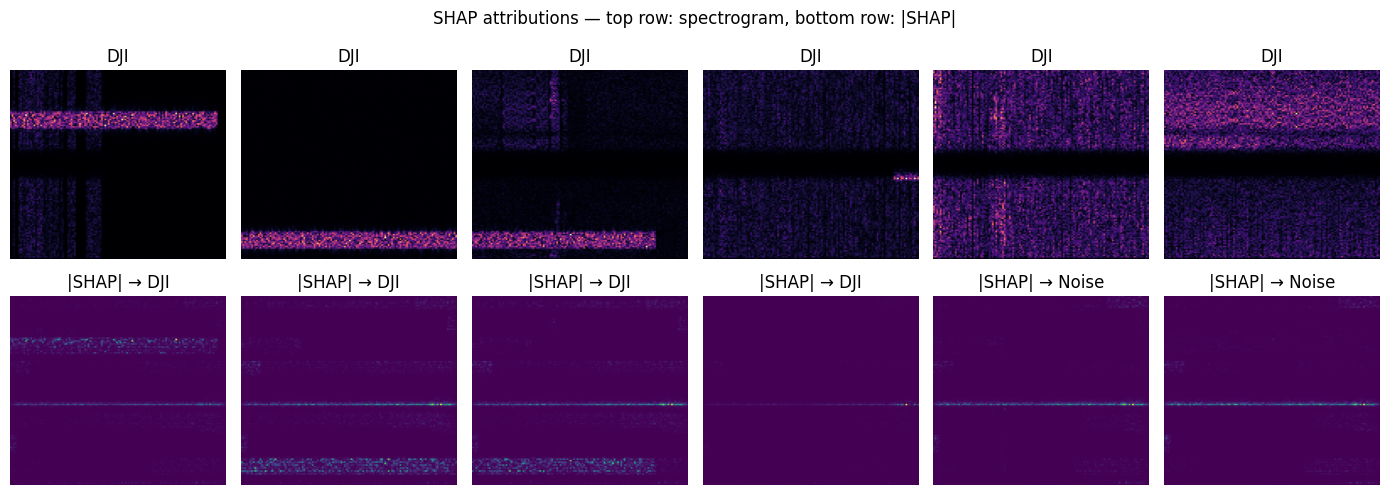

In [8]:
shap = interp_mod._try_import_shap()
shap_attr = None
if shap is not None:
    explainer = shap.DeepExplainer(model, xb_dev[6:38])
    shap_attr = explainer.shap_values(xb_dev[:6], check_additivity=False)

if shap_attr is None:
    print("shap not installed: pip install shap")
else:
    pred_class = model(xb_dev[:6]).argmax(-1).cpu().numpy()
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    for j in range(6):
        spec = (xb[j, 0] ** 2 + xb[j, 1] ** 2).sqrt().numpy()
        axes[0, j].imshow(spec, aspect="auto", origin="lower", cmap="magma")
        axes[0, j].set_title(f"{CLASS_NAMES[int(yb[j])]}")
        axes[0, j].axis("off")
        attr = np.abs(shap_attr[j, :, :, :, int(pred_class[j])]).sum(axis=0)
        axes[1, j].imshow(attr, aspect="auto", origin="lower", cmap="viridis")
        axes[1, j].set_title(f"|SHAP| → {CLASS_NAMES[int(pred_class[j])]}")
        axes[1, j].axis("off")
    plt.suptitle("SHAP attributions — top row: spectrogram, bottom row: |SHAP|")
    plt.tight_layout()
    plt.savefig(CFG.figures("04_interpretability") / "shap_examples.png", dpi=120)
    plt.show()


## 4. LIME (image variant με super-pixels)

In [9]:
import sys, importlib

# Forcefully nuke ALL src cache
for k in [k for k in sys.modules if k.startswith("src")]:
    del sys.modules[k]
importlib.invalidate_caches()

# Hard re-import + REBIND το global name "interp_mod"
import src.interpret
interp_mod = src.interpret

# Verify
import inspect
src_text = inspect.getsource(interp_mod.lime_image_explanation)
print("Function name:", interp_mod.lime_image_explanation.__name__)
print("Defined in file:", interp_mod.lime_image_explanation.__code__.co_filename)
print("Has 'slic':", "slic" in src_text)
print("Has 'segmentation_fn=segmentation_fn':", "segmentation_fn=segmentation_fn" in src_text)


Function name: lime_image_explanation
Defined in file: /content/drive/MyDrive/rf_drone_defense/src/interpret.py
Has 'slic': True
Has 'segmentation_fn=segmentation_fn': True


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

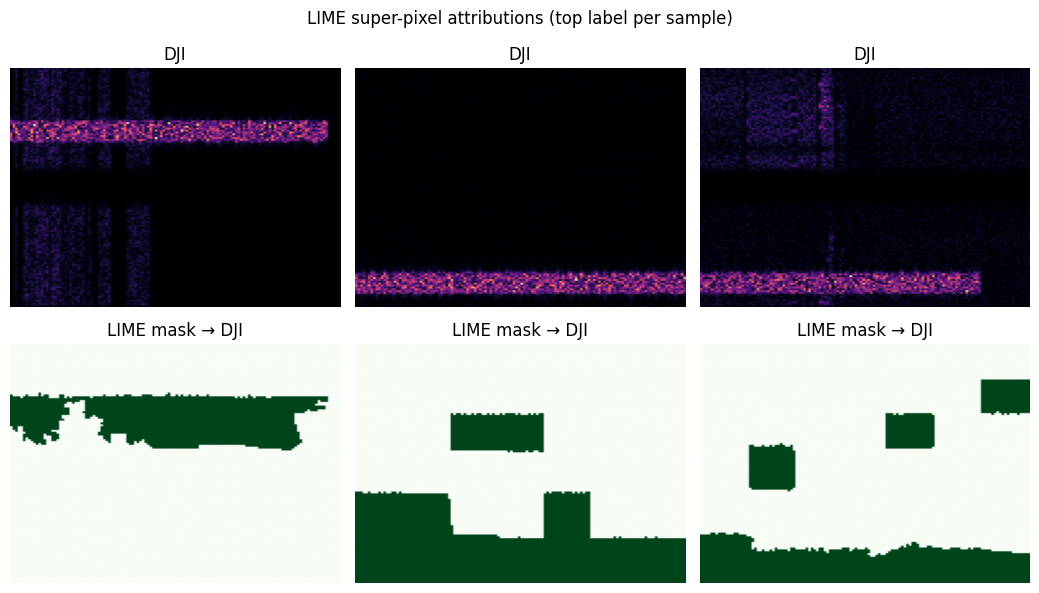

In [10]:
#!pip install -q lime

n_show = 3
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 3.5, 6))
for j in range(n_show):
    out = interp_mod.lime_image_explanation(model, xb[j].numpy(), n_samples=400, n_top_labels=2)
    spec = (xb[j, 0] ** 2 + xb[j, 1] ** 2).sqrt().numpy()
    axes[0, j].imshow(spec, aspect="auto", origin="lower", cmap="magma")
    axes[0, j].set_title(f"{CLASS_NAMES[int(yb[j])]}"); axes[0, j].axis("off")
    if out is None:
        axes[1, j].text(0.5, 0.5, "lime not installed", ha="center"); axes[1, j].axis("off")
    else:
        top_lbl = list(out.keys())[0]   # LIME επιστρεφει τα labels ordered by confidence
        axes[1, j].imshow(out[top_lbl], aspect="auto", origin="lower", cmap="Greens")
        axes[1, j].set_title(f"LIME mask → {CLASS_NAMES[top_lbl]}")
        axes[1, j].axis("off")
plt.suptitle("LIME super-pixel attributions (top label per sample)")
plt.tight_layout()
plt.savefig(CFG.figures("04_interpretability") / "lime_examples.png", dpi=120)
plt.show()


## 5. Grad-CAM (saliency-method default)

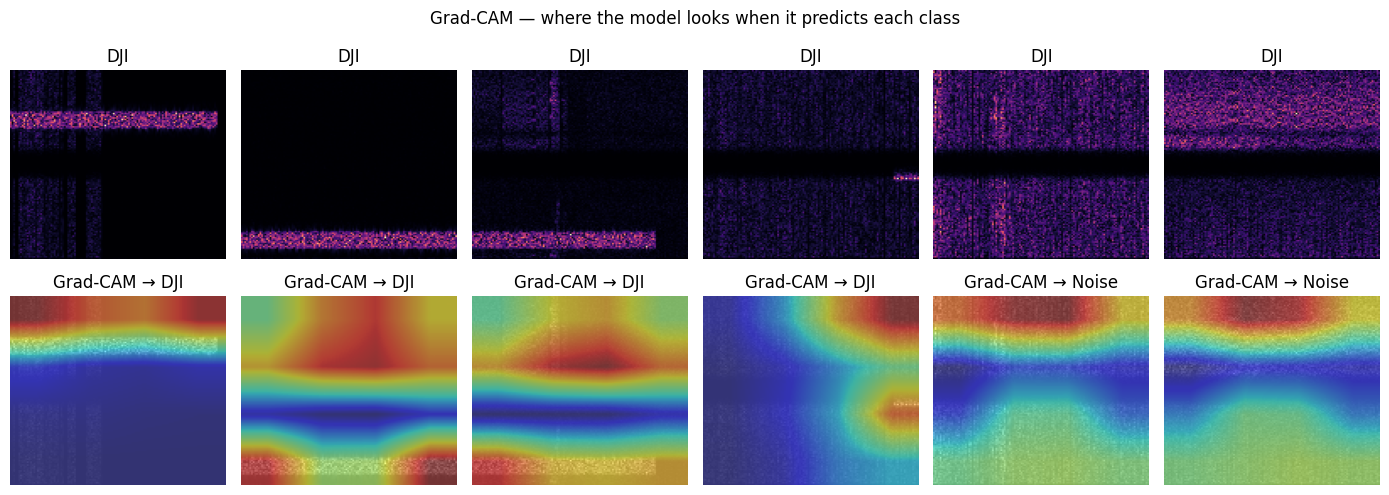

In [11]:
pred = model(xb_dev[:6]).argmax(-1)
cam = interp_mod.grad_cam(model, xb_dev[:6], pred)
# Upsample CAM (which is at layer4 resolution) to 128×128 for overlay
import torch.nn.functional as F
cam_up = F.interpolate(cam.unsqueeze(1), size=(128, 128), mode="bilinear", align_corners=False).squeeze(1)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for j in range(6):
    spec = (xb[j, 0] ** 2 + xb[j, 1] ** 2).sqrt().numpy()
    axes[0, j].imshow(spec, aspect="auto", origin="lower", cmap="magma")
    axes[0, j].set_title(f"{CLASS_NAMES[int(yb[j])]}"); axes[0, j].axis("off")
    axes[1, j].imshow(spec, aspect="auto", origin="lower", cmap="gray", alpha=0.6)
    axes[1, j].imshow(cam_up[j].cpu().numpy(), aspect="auto", origin="lower", cmap="jet", alpha=0.5)
    axes[1, j].set_title(f"Grad-CAM → {CLASS_NAMES[int(pred[j])]}"); axes[1, j].axis("off")
plt.suptitle("Grad-CAM — where the model looks when it predicts each class")
plt.tight_layout()
plt.savefig(CFG.figures("04_interpretability") / "gradcam_examples.png", dpi=120)
plt.show()


## 6. ProtoPNet sketch — Nearest training prototypes

In [12]:
# Embed the query batch through the trained backbone.
with torch.no_grad():
    feats_q = model.features(xb_dev[:5]).cpu().numpy()

tr_emb = np.load(art01 / "embeddings_train.npz")
protos = interp_mod.nearest_prototype(
    sample_features=feats_q,
    reference_features=tr_emb["features"],
    reference_labels=tr_emb["y"],
    reference_snr=tr_emb["snr"],
    k=3,
)
for j, entry in enumerate(protos):
    print(f"Query {j} — true label {CLASS_NAMES[int(yb[j])]}:")
    for hit in entry["top_k"]:
        print(f"  ref #{hit['ref_index']:>6}  sim {hit['similarity']:.3f}  "
              f"label {CLASS_NAMES[hit['ref_label']]} @ {hit['ref_snr']} dB")
    print()


Query 0 — true label DJI:
  ref #  4117  sim 0.998  label DJI @ 10 dB
  ref #  8630  sim 0.998  label DJI @ 16 dB
  ref # 28892  sim 0.998  label DJI @ 24 dB

Query 1 — true label DJI:
  ref # 51653  sim 1.000  label DJI @ 22 dB
  ref # 17684  sim 1.000  label DJI @ 28 dB
  ref # 66995  sim 1.000  label DJI @ 30 dB

Query 2 — true label DJI:
  ref # 57747  sim 0.996  label DJI @ 2 dB
  ref # 18394  sim 0.994  label DJI @ 4 dB
  ref # 59244  sim 0.994  label DJI @ 10 dB

Query 3 — true label DJI:
  ref # 30052  sim 0.986  label DJI @ 4 dB
  ref # 57174  sim 0.986  label DJI @ -8 dB
  ref # 44238  sim 0.984  label DJI @ -6 dB

Query 4 — true label DJI:
  ref # 27149  sim 0.999  label Noise @ -18 dB
  ref # 66089  sim 0.999  label Noise @ -4 dB
  ref # 24485  sim 0.999  label DJI @ -20 dB



## 7. Permutation Importance στα RF-DSP features

In [13]:
# Build the same RF-DSP feature matrix you used in 03_causal, train a simple
# logistic regression on (RF features → friend/foe), then permutation-shuffle
# each feature to measure its causal contribution.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("Extracting RF features (this is slow — small subset)…")
pack_iq = data_mod.load_arrays(CFG.dataset_path, with_iq=True)
x_iq = pack_iq["x_iq"]

# Sub-sample 1500 from test for tractability
rng = np.random.default_rng(CFG.seed)
sub = test_idx[rng.choice(len(test_idx), size=min(1500, len(test_idx)), replace=False)]
feats_list = [causal_mod.extract_rf_features(x_iq[int(i)].numpy()) for i in sub]
X = np.stack(feats_list)
y_friend = np.isin(y[sub].numpy(), FRIENDLY_IDX).astype(int)

scaler = StandardScaler().fit(X)
X_std = scaler.transform(X)
clf = LogisticRegression(max_iter=1000).fit(X_std, y_friend)

importances = interp_mod.permutation_importance_classifier(
    predict_fn=lambda Z: clf.predict(scaler.transform(Z)),
    X=X, y=y_friend,
    feature_names=causal_mod.RF_FEATURE_NAMES,
    n_repeats=20,
)
for imp in importances:
    print(f"  {imp['feature']:>22}: {imp['importance_mean']:+.4f} ± {imp['importance_std']:.4f}")


Extracting RF features (this is slow — small subset)…
      bandwidth_hz_90pct: +0.1218 ± 0.0054
            dominant_psd: +0.0878 ± 0.0072
          duty_cycle_est: +0.0547 ± 0.0076
               power_max: +0.0080 ± 0.0029
      magnitude_kurtosis: +0.0061 ± 0.0027
               power_std: +0.0048 ± 0.0015
              power_mean: +0.0040 ± 0.0016
        dominant_freq_hz: +0.0017 ± 0.0011


## 8. Persistence

In [14]:
import json
out = CFG.artefacts("04_interpretability")
with (out / "interpretability_summary.json").open("w", encoding="utf-8") as f:
    json.dump({
        "shap_available": interp_mod._try_import_shap() is not None,
        "lime_available": interp_mod._try_import_lime() is not None,
        "permutation_importance": importances,
        "n_examples_in_figures": 6,
    }, f, indent=2, default=str)
print("Saved:", out)


Saved: /content/drive/MyDrive/rf_drone_defense/artefacts/04_interpretability_pgd
